# Resuloción de Ejercicios: Preparación y Procesamiento de Datos en Python

In [1]:
# General imports for the entire notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded successfully")

Libraries loaded successfully


---
## Ejercicio 1: Normalización Min-Max

Fórmula:

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Datos: [10, 20, 30, 40, 50]

In [2]:
# --- Exercise 1: Min-Max Normalization ---

data = np.array([10, 20, 30, 40, 50])

# 1. Manual Min-Max normalization
x_min = data.min()
x_max = data.max()
normalized_manual = (data - x_min) / (x_max - x_min)

print("Original data:", data)
print(f"X_min = {x_min}, X_max = {x_max}")
print("Manually normalized:", normalized_manual)

# 2. Verify results are between 0 and 1
print(f"\nMin of normalized: {normalized_manual.min()} (should be 0)")
print(f"Max of normalized: {normalized_manual.max()} (should be 1)")
assert normalized_manual.min() >= 0 and normalized_manual.max() <= 1, \
    "Values are NOT in [0, 1]!"
print("✅ All values are in the range [0, 1]")

Original data: [10 20 30 40 50]
X_min = 10, X_max = 50
Manually normalized: [0.   0.25 0.5  0.75 1.  ]

Min of normalized: 0.0 (should be 0)
Max of normalized: 1.0 (should be 1)
✅ All values are in the range [0, 1]


In [3]:
# 3. Using sklearn MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_sklearn = scaler.fit_transform(data.reshape(-1, 1)).flatten()

print("Sklearn normalized:", normalized_sklearn)
print(
    "Manual == Sklearn?",
    np.allclose(normalized_manual, normalized_sklearn),
)      

Sklearn normalized: [0.   0.25 0.5  0.75 1.  ]
Manual == Sklearn? True


---
## Ejercicio 2: Estandarización (Z-Score)

Fórmula:

$$Z = \frac{X - \mu}{\sigma}$$

Datos: [2, 4, 4, 4, 5, 5, 7, 9]

In [4]:
# --- Exercise 2: Z-Score Standardization ---

data = np.array([2, 4, 4, 4, 5, 5, 7, 9])

# 1. Mean
mean = data.mean()
print(f"1. Mean (μ): {mean}")

# 2. Standard deviation (population)
std = data.std()
print(f"2. Standard deviation (σ): {std:.4f}")

# 3. Standardize each value
z_scores = (data - mean) / std
print(f"\n3. Z-scores: {np.round(z_scores, 4)}")

# Step-by-step detail
print("\nStep-by-step:")
for x, z in zip(data, z_scores):
    print(f"   X={x}  →  Z = ({x} - {mean}) / {std:.4f} = {z:.4f}")

1. Mean (μ): 5.0
2. Standard deviation (σ): 2.0000

3. Z-scores: [-1.5 -0.5 -0.5 -0.5  0.   0.   1.   2. ]

Step-by-step:
   X=2  →  Z = (2 - 5.0) / 2.0000 = -1.5000
   X=4  →  Z = (4 - 5.0) / 2.0000 = -0.5000
   X=4  →  Z = (4 - 5.0) / 2.0000 = -0.5000
   X=4  →  Z = (4 - 5.0) / 2.0000 = -0.5000
   X=5  →  Z = (5 - 5.0) / 2.0000 = 0.0000
   X=5  →  Z = (5 - 5.0) / 2.0000 = 0.0000
   X=7  →  Z = (7 - 5.0) / 2.0000 = 1.0000
   X=9  →  Z = (9 - 5.0) / 2.0000 = 2.0000


In [5]:
# 4. Verify mean ≈ 0 and std ≈ 1
print(f"Mean of Z-scores:  {z_scores.mean():.10f}  (should be ≈ 0)")
print(f"Std of Z-scores:   {z_scores.std():.10f}   (should be ≈ 1)")
print("✅ Standardization verified")

Mean of Z-scores:  0.0000000000  (should be ≈ 0)
Std of Z-scores:   1.0000000000   (should be ≈ 1)
✅ Standardization verified


---
## Ejercicio 3: Comparación de Técnicas (MinMaxScaler vs StandardScaler)

In [6]:
# --- Exercise 3: Comparison of Techniques ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = np.array([100, 200, 300, 400, 500]).reshape(-1, 1)

# 1. MinMaxScaler
minmax = MinMaxScaler()
data_minmax = minmax.fit_transform(data)

# 2. StandardScaler
standard = StandardScaler()
data_standard = standard.fit_transform(data)

# Results comparison table
comparison = pd.DataFrame({
    "Original": data.flatten(),
    "MinMax (0-1)": data_minmax.flatten(),
    "Standard (Z)": data_standard.flatten(),
})
print(comparison.to_string(index=False))

print(f"\n--- MinMaxScaler ---")
print(f"Range: [{data_minmax.min()}, {data_minmax.max()}]")

print(f"\n--- StandardScaler ---")
print(f"Mean: {data_standard.mean():.4f}, Std: {data_standard.std():.4f}")

 Original  MinMax (0-1)  Standard (Z)
      100          0.00     -1.414214
      200          0.25     -0.707107
      300          0.50      0.000000
      400          0.75      0.707107
      500          1.00      1.414214

--- MinMaxScaler ---
Range: [0.0, 1.0]

--- StandardScaler ---
Mean: 0.0000, Std: 1.0000


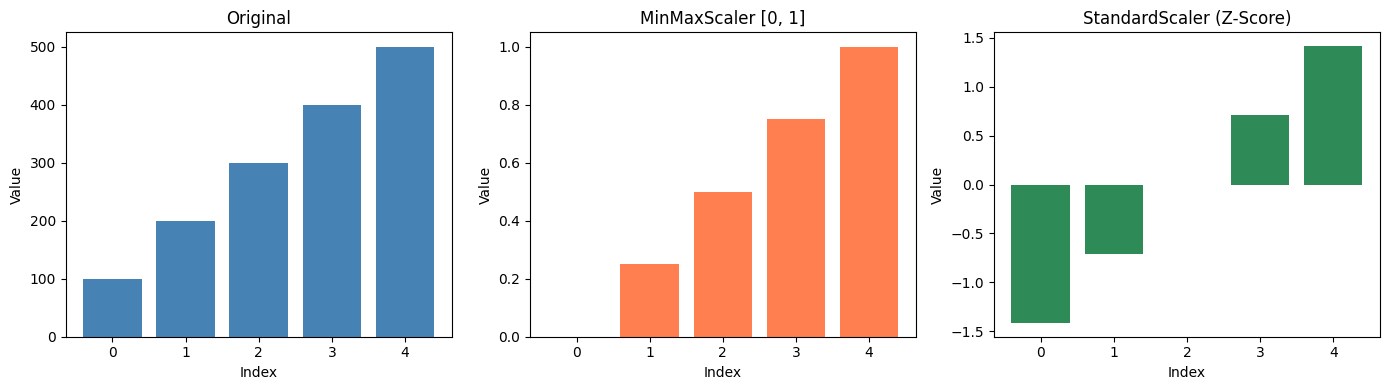

In [7]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(range(5), data.flatten(), color="steelblue")
axes[0].set_title("Original")
axes[0].set_ylabel("Value")

axes[1].bar(range(5), data_minmax.flatten(), color="coral")
axes[1].set_title("MinMaxScaler [0, 1]")
axes[1].set_ylabel("Value")

axes[2].bar(range(5), data_standard.flatten(), color="seagreen")
axes[2].set_title("StandardScaler (Z-Score)")
axes[2].set_ylabel("Value")

for ax in axes:
    ax.set_xlabel("Index")

plt.tight_layout()
plt.show()

---
## Ejercicio 4: Identificación de Valores Faltantes

In [8]:
# --- Exercise 4: Identifying Missing Values ---

df = pd.DataFrame({
    "A": [1, 2, np.nan, 4, 5],
    "B": [np.nan, 2, 3, 4, np.nan],
    "C": [1, 2, 3, 4, 5],
})

print("DataFrame:")
print(df)

DataFrame:
     A    B  C
0  1.0  NaN  1
1  2.0  2.0  2
2  NaN  3.0  3
3  4.0  4.0  4
4  5.0  NaN  5


In [9]:
# 1. Identify missing values with isnull()
print("1. Missing values mask (isnull()):")
print(df.isnull())

1. Missing values mask (isnull()):
       A      B      C
0  False   True  False
1  False  False  False
2   True  False  False
3  False  False  False
4  False   True  False


In [10]:
# 2. Count missing values per column
print("2. Missing values count per column:")
print(df.isnull().sum())

2. Missing values count per column:
A    1
B    2
C    0
dtype: int64


In [11]:
# 3. Percentage of missing values per column
total_rows = len(df)
missing_pct = (df.isnull().sum() / total_rows) * 100

print("3. Percentage of missing values:")
print(missing_pct.to_string())
print(f"\n   Total rows: {total_rows}")

3. Percentage of missing values:
A    20.0
B    40.0
C     0.0

   Total rows: 5


In [12]:
# 4. Show only rows with missing values
print("4. Rows with at least one missing value:")
rows_with_na = df[df.isnull().any(axis=1)]
print(rows_with_na)

4. Rows with at least one missing value:
     A    B  C
0  1.0  NaN  1
2  NaN  3.0  3
4  5.0  NaN  5


---
## Ejercicio 5: Estrategias de Imputación

In [13]:
# --- Exercise 5: Imputation Strategies ---

# Recreate the DataFrame for each strategy
df_original = pd.DataFrame({
    "A": [1, 2, np.nan, 4, 5],
    "B": [np.nan, 2, 3, 4, np.nan],
    "C": [1, 2, 3, 4, 5],
})

print("Original DataFrame:")
print(df_original)
print()

# 1. Drop rows with missing values
df_drop_rows = df_original.dropna()
print("1. dropna() — Drop rows:")
print(df_drop_rows)
print()

# 2. Drop columns with missing values
df_drop_cols = df_original.dropna(axis=1)
print("2. dropna(axis=1) — Drop columns:")
print(df_drop_cols)

Original DataFrame:
     A    B  C
0  1.0  NaN  1
1  2.0  2.0  2
2  NaN  3.0  3
3  4.0  4.0  4
4  5.0  NaN  5

1. dropna() — Drop rows:
     A    B  C
1  2.0  2.0  2
3  4.0  4.0  4

2. dropna(axis=1) — Drop columns:
   C
0  1
1  2
2  3
3  4
4  5


In [14]:
# 3. Impute with mean
df_mean = df_original.copy()
df_mean = df_mean.fillna(df_mean.mean())
print("3. Impute with MEAN:")
print(df_mean)
print()

# 4. Impute with median
df_median = df_original.copy()
df_median = df_median.fillna(df_median.median())
print("4. Impute with MEDIAN:")
print(df_median)

3. Impute with MEAN:
     A    B  C
0  1.0  3.0  1
1  2.0  2.0  2
2  3.0  3.0  3
3  4.0  4.0  4
4  5.0  3.0  5

4. Impute with MEDIAN:
     A    B  C
0  1.0  3.0  1
1  2.0  2.0  2
2  3.0  3.0  3
3  4.0  4.0  4
4  5.0  3.0  5


In [15]:
# 5. Forward fill (propagate last valid value forward)
df_ffill = df_original.copy()
df_ffill = df_ffill.ffill()
print("5. Forward Fill (ffill):")
print(df_ffill)
print()

# 6. Backward fill (propagate next valid value backward)
df_bfill = df_original.copy()
df_bfill = df_bfill.bfill()
print("6. Backward Fill (bfill):")
print(df_bfill)

5. Forward Fill (ffill):
     A    B  C
0  1.0  NaN  1
1  2.0  2.0  2
2  2.0  3.0  3
3  4.0  4.0  4
4  5.0  4.0  5

6. Backward Fill (bfill):
     A    B  C
0  1.0  2.0  1
1  2.0  2.0  2
2  4.0  3.0  3
3  4.0  4.0  4
4  5.0  NaN  5


---
## Ejercicio 6: Imputación Avanzada con SimpleImputer

In [16]:
# --- Exercise 6: Advanced Imputation with SimpleImputer ---
from sklearn.impute import SimpleImputer

df_original = pd.DataFrame({
    "A": [1, 2, np.nan, 4, 5],
    "B": [np.nan, 2, 3, 4, np.nan],
    "C": [1, 2, 3, 4, 5],
})

strategies = ["mean", "median", "most_frequent"]

for strategy in strategies:
    imputer = SimpleImputer(strategy=strategy)
    result = imputer.fit_transform(df_original)
    df_result = pd.DataFrame(result, columns=df_original.columns)
    print(f"Strategy: {strategy}")
    print(df_result)
    print()

Strategy: mean
     A    B    C
0  1.0  3.0  1.0
1  2.0  2.0  2.0
2  3.0  3.0  3.0
3  4.0  4.0  4.0
4  5.0  3.0  5.0

Strategy: median
     A    B    C
0  1.0  3.0  1.0
1  2.0  2.0  2.0
2  3.0  3.0  3.0
3  4.0  4.0  4.0
4  5.0  3.0  5.0

Strategy: most_frequent
     A    B    C
0  1.0  2.0  1.0
1  2.0  2.0  2.0
2  1.0  3.0  3.0
3  4.0  4.0  4.0
4  5.0  2.0  5.0



In [17]:
# Constant strategy
imputer_const = SimpleImputer(strategy="constant", fill_value=-999)
result_const = imputer_const.fit_transform(df_original)
df_const = pd.DataFrame(result_const, columns=df_original.columns)
print("Strategy: constant (fill_value=-999)")
print(df_const)

Strategy: constant (fill_value=-999)
       A      B    C
0    1.0 -999.0  1.0
1    2.0    2.0  2.0
2 -999.0    3.0  3.0
3    4.0    4.0  4.0
4    5.0 -999.0  5.0


---
## Ejercicio 7: Detección de Outliers — Método IQR

$$IQR = Q3 - Q1$$
$$\text{Lower bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper bound} = Q3 + 1.5 \times IQR$$

In [18]:
# --- Exercise 7: IQR Method ---

data = np.array([10, 12, 14, 15, 16, 18, 20, 22, 25, 100])

# 1. Q1
q1 = np.percentile(data, 25)
print(f"1. Q1 (25th percentile): {q1}")

# 2. Q3
q3 = np.percentile(data, 75)
print(f"2. Q3 (75th percentile): {q3}")

# 3. IQR
iqr = q3 - q1
print(f"3. IQR = Q3 - Q1 = {q3} - {q1} = {iqr}")

# 4. Lower bound
lower = q1 - 1.5 * iqr
print(f"4. Lower bound = {q1} - 1.5 * {iqr} = {lower}")

# 5. Upper bound
upper = q3 + 1.5 * iqr
print(f"5. Upper bound = {q3} + 1.5 * {iqr} = {upper}")

# 6. Identify outliers
outliers = data[(data < lower) | (data > upper)]
print(f"\n6. Outliers: {outliers}")
print(f"   Non-outliers: {data[(data >= lower) & (data <= upper)]}")

1. Q1 (25th percentile): 14.25
2. Q3 (75th percentile): 21.5
3. IQR = Q3 - Q1 = 21.5 - 14.25 = 7.25
4. Lower bound = 14.25 - 1.5 * 7.25 = 3.375
5. Upper bound = 21.5 + 1.5 * 7.25 = 32.375

6. Outliers: [100]
   Non-outliers: [10 12 14 15 16 18 20 22 25]


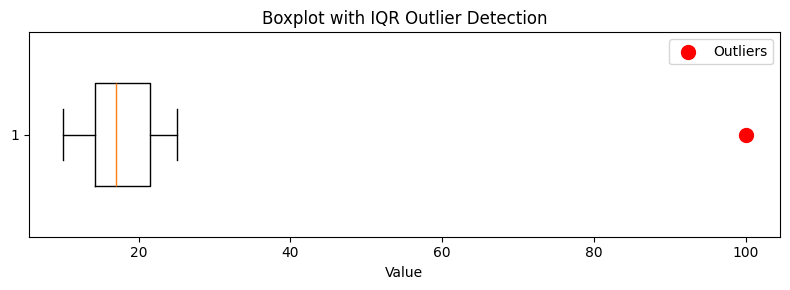

In [19]:
# Boxplot visualization
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(data, vert=False, widths=0.5)
ax.scatter(
    outliers,
    [1] * len(outliers),
    color="red",
    s=100,
    zorder=5,
    label="Outliers",
)
ax.set_title("Boxplot with IQR Outlier Detection")
ax.set_xlabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

---
## Ejercicio 8: Detección de Outliers — Método Z-Score

Un valor se considera outlier si \( |Z| > 3 \) (o a veces \( |Z| > 2 \)).

In [20]:
# --- Exercise 8: Z-Score Method ---

data = np.array([10, 12, 14, 15, 16, 18, 20, 22, 25, 100])

z_scores = stats.zscore(data)

print("Value  |  Z-Score  |  Outlier (|Z|>3)?")
print("-" * 40)
for val, z in zip(data, z_scores):
    is_outlier = "⚠️ YES" if abs(z) > 3 else "   no"
    print(f"  {val:>4}  |  {z:>7.4f}  |  {is_outlier}")

outlier_indices = np.where(np.abs(z_scores) > 3)[0]
print(f"\nOutlier indices (|Z|>3): {outlier_indices}")
print(f"Outlier values: {data[outlier_indices]}")

# Note: with threshold = 2
outlier_indices_2 = np.where(np.abs(z_scores) > 2)[0]
print(f"\nWith threshold |Z|>2: {data[outlier_indices_2]}")

Value  |  Z-Score  |  Outlier (|Z|>3)?
----------------------------------------
    10  |  -0.6007  |     no
    12  |  -0.5216  |     no
    14  |  -0.4426  |     no
    15  |  -0.4031  |     no
    16  |  -0.3636  |     no
    18  |  -0.2845  |     no
    20  |  -0.2055  |     no
    22  |  -0.1265  |     no
    25  |  -0.0079  |     no
   100  |   2.9559  |     no

Outlier indices (|Z|>3): []
Outlier values: []

With threshold |Z|>2: [100]


---
## Ejercicio 9: Manejo de Outliers
Técnicas:
1. Eliminar outliers
2. Capping (reemplazar con límites)
3. Transformación logarítmica
4. Transformación Box-Cox

In [21]:
# --- Exercise 9: Handling Outliers ---

data = np.array([10, 12, 14, 15, 16, 18, 20, 22, 25, 100])

# Recalculate IQR bounds
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# 1. Remove outliers
data_removed = data[(data >= lower) & (data <= upper)]
print("1. Remove outliers:")
print(f"   Original: {data}")
print(f"   Cleaned:  {data_removed}")
print()

# 2. Capping (winsorize) — replace outliers with boundary values
data_capped = data.copy().astype(float)
data_capped[data_capped < lower] = lower
data_capped[data_capped > upper] = upper
print("2. Capping (winsorize):")
print(f"   Capped:   {data_capped}")
print(f"   Bounds:   [{lower}, {upper}]")

1. Remove outliers:
   Original: [ 10  12  14  15  16  18  20  22  25 100]
   Cleaned:  [10 12 14 15 16 18 20 22 25]

2. Capping (winsorize):
   Capped:   [10.    12.    14.    15.    16.    18.    20.    22.    25.    32.375]
   Bounds:   [3.375, 32.375]


In [22]:
# 3. Log transformation
data_log = np.log1p(data)  # log(1 + x) to handle zero-safe
print("3. Log transformation (log1p):")
print(f"   Original: {data}")
print(f"   Log:      {np.round(data_log, 4)}")
print()

# 4. Box-Cox transformation (requires positive data)
from scipy.stats import boxcox

data_boxcox, lambda_bc = boxcox(data.astype(float))
print(f"4. Box-Cox transformation (λ = {lambda_bc:.4f}):")
print(f"   Transformed: {np.round(data_boxcox, 4)}")

3. Log transformation (log1p):
   Original: [ 10  12  14  15  16  18  20  22  25 100]
   Log:      [2.3979 2.5649 2.7081 2.7726 2.8332 2.9444 3.0445 3.1355 3.2581 4.6151]

4. Box-Cox transformation (λ = -1.0981):
   Transformed: [0.838  0.8512 0.8605 0.8641 0.8673 0.8726 0.8767 0.8801 0.8841 0.9049]


---
## Ejercicio 10: Codificación de Variables Categóricas
- Label Encoding
- One-Hot Encoding (pandas & sklearn)

In [23]:
# --- Exercise 10: Categorical Encoding ---

df = pd.DataFrame({
    "color": ["rojo", "azul", "verde", "rojo", "verde"],
    "talla": ["S", "M", "L", "S", "M"],
})

print("Original DataFrame:")
print(df)

Original DataFrame:
   color talla
0   rojo     S
1   azul     M
2  verde     L
3   rojo     S
4  verde     M


In [24]:
# 1. Label Encoding
from sklearn.preprocessing import LabelEncoder

df_label = df.copy()

le_color = LabelEncoder()
le_talla = LabelEncoder()

df_label["color_encoded"] = le_color.fit_transform(df_label["color"])
df_label["talla_encoded"] = le_talla.fit_transform(df_label["talla"])

print("1. Label Encoding:")
print(df_label)
print(f"\n   color mapping: {dict(zip(le_color.classes_, le_color.transform(le_color.classes_)))}")
print(f"   talla mapping: {dict(zip(le_talla.classes_, le_talla.transform(le_talla.classes_)))}")

1. Label Encoding:
   color talla  color_encoded  talla_encoded
0   rojo     S              1              2
1   azul     M              0              1
2  verde     L              2              0
3   rojo     S              1              2
4  verde     M              2              1

   color mapping: {'azul': np.int64(0), 'rojo': np.int64(1), 'verde': np.int64(2)}
   talla mapping: {'L': np.int64(0), 'M': np.int64(1), 'S': np.int64(2)}


In [25]:
# 2. One-Hot Encoding with pandas get_dummies
df_dummies = pd.get_dummies(df, dtype=int)

print("2. One-Hot Encoding (pd.get_dummies):")
print(df_dummies)

2. One-Hot Encoding (pd.get_dummies):
   color_azul  color_rojo  color_verde  talla_L  talla_M  talla_S
0           0           1            0        0        0        1
1           1           0            0        0        1        0
2           0           0            1        1        0        0
3           0           1            0        0        0        1
4           0           0            1        0        1        0


In [26]:
# 3. One-Hot Encoding with sklearn
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[["color", "talla"]])

feature_names = ohe.get_feature_names_out(["color", "talla"])
df_ohe = pd.DataFrame(encoded, columns=feature_names)

print("3. One-Hot Encoding (sklearn):")
print(df_ohe)

3. One-Hot Encoding (sklearn):
   color_azul  color_rojo  color_verde  talla_L  talla_M  talla_S
0         0.0         1.0          0.0      0.0      0.0      1.0
1         1.0         0.0          0.0      0.0      1.0      0.0
2         0.0         0.0          1.0      1.0      0.0      0.0
3         0.0         1.0          0.0      0.0      0.0      1.0
4         0.0         0.0          1.0      0.0      1.0      0.0


---
## Ejercicio 11: Transformaciones Numéricas

In [27]:
# --- Exercise 11: Numeric Transformations ---

data = np.array([1, 2, 3, 4, 5, 10, 20, 30])

# 1. Natural log
data_log = np.log(data)
print("1. Natural Log:")
print(f"   Original:    {data}")
print(f"   log(x):      {np.round(data_log, 4)}")
print()

# 2. Square root
data_sqrt = np.sqrt(data)
print("2. Square Root:")
print(f"   sqrt(x):     {np.round(data_sqrt, 4)}")
print()

# 3. Box-Cox
data_boxcox, lam = boxcox(data.astype(float))
print(f"3. Box-Cox (λ={lam:.4f}):")
print(f"   Transformed: {np.round(data_boxcox, 4)}")
print()

# 4. Discretization (binning)
bins = [0, 5, 15, 35]
labels = ["low", "medium", "high"]
data_binned = pd.cut(data, bins=bins, labels=labels)
print("4. Discretization (binning):")
print(f"   Bins: {bins}")
for val, cat in zip(data, data_binned):
    print(f"   {val:>3} → {cat}")

1. Natural Log:
   Original:    [ 1  2  3  4  5 10 20 30]
   log(x):      [0.     0.6931 1.0986 1.3863 1.6094 2.3026 2.9957 3.4012]

2. Square Root:
   sqrt(x):     [1.     1.4142 1.7321 2.     2.2361 3.1623 4.4721 5.4772]

3. Box-Cox (λ=-0.0809):
   Transformed: [0.     0.6741 1.0512 1.3114 1.5091 2.1009 2.6605 2.9736]

4. Discretization (binning):
   Bins: [0, 5, 15, 35]
     1 → low
     2 → low
     3 → low
     4 → low
     5 → low
    10 → medium
    20 → high
    30 → high


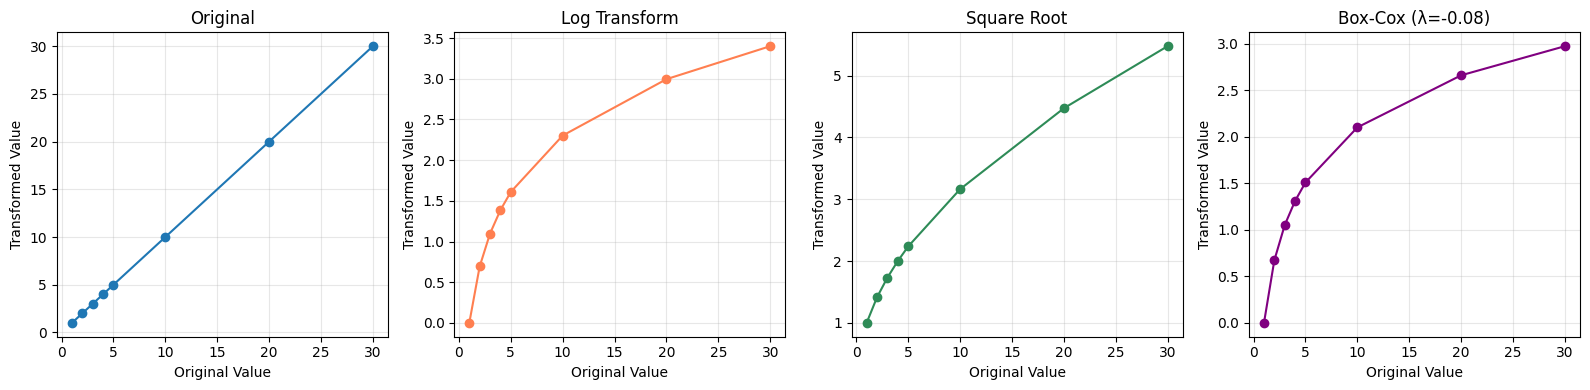

In [28]:
# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(data, data, "o-")
axes[0].set_title("Original")

axes[1].plot(data, data_log, "o-", color="coral")
axes[1].set_title("Log Transform")

axes[2].plot(data, data_sqrt, "o-", color="seagreen")
axes[2].set_title("Square Root")

axes[3].plot(data, data_boxcox, "o-", color="purple")
axes[3].set_title(f"Box-Cox (λ={lam:.2f})")

for ax in axes:
    ax.set_xlabel("Original Value")
    ax.set_ylabel("Transformed Value")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Ejercicio 12: Feature Engineering

In [29]:
# --- Exercise 12: Feature Engineering ---

df = pd.DataFrame({
    "price": [100, 200, 150, 300, 250],
    "quantity": [10, 5, 8, 3, 6],
    "date": pd.to_datetime([
        "2024-01-15", "2024-03-22", "2024-06-10",
        "2024-09-05", "2024-12-20",
    ]),
    "category": ["A", "B", "A", "C", "B"],
})

print("Original DataFrame:")
print(df)

Original DataFrame:
   price  quantity       date category
0    100        10 2024-01-15        A
1    200         5 2024-03-22        B
2    150         8 2024-06-10        A
3    300         3 2024-09-05        C
4    250         6 2024-12-20        B


In [30]:
# 1. Ratio between columns
df["price_per_unit"] = df["price"] / df["quantity"]
print("1. Ratio (price / quantity):")
print(df[["price", "quantity", "price_per_unit"]])
print()

# 2. Difference between columns
df["price_minus_qty"] = df["price"] - df["quantity"]
print("2. Difference (price - quantity):")
print(df[["price", "quantity", "price_minus_qty"]])
print()

# 3. Binary indicators
df["is_expensive"] = (df["price"] > 200).astype(int)
df["high_quantity"] = (df["quantity"] > 5).astype(int)
print("3. Binary indicators:")
print(df[["price", "is_expensive", "quantity", "high_quantity"]])

1. Ratio (price / quantity):
   price  quantity  price_per_unit
0    100        10       10.000000
1    200         5       40.000000
2    150         8       18.750000
3    300         3      100.000000
4    250         6       41.666667

2. Difference (price - quantity):
   price  quantity  price_minus_qty
0    100        10               90
1    200         5              195
2    150         8              142
3    300         3              297
4    250         6              244

3. Binary indicators:
   price  is_expensive  quantity  high_quantity
0    100             0        10              1
1    200             0         5              0
2    150             0         8              1
3    300             1         3              0
4    250             1         6              1


In [31]:
# 4. Polynomial features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
numeric_cols = df[["price", "quantity"]]
poly_features = poly.fit_transform(numeric_cols)
poly_names = poly.get_feature_names_out(["price", "quantity"])

df_poly = pd.DataFrame(poly_features, columns=poly_names)
print("4. Polynomial Features (degree=2):")
print(df_poly)

4. Polynomial Features (degree=2):
   price  quantity  price^2  price quantity  quantity^2
0  100.0      10.0  10000.0          1000.0       100.0
1  200.0       5.0  40000.0          1000.0        25.0
2  150.0       8.0  22500.0          1200.0        64.0
3  300.0       3.0  90000.0           900.0         9.0
4  250.0       6.0  62500.0          1500.0        36.0


In [32]:
# 5. DateTime features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

print("5. DateTime Features:")
print(
    df[["date", "year", "month", "day", "day_of_week", "quarter", "is_weekend"]]
)

5. DateTime Features:
        date  year  month  day  day_of_week  quarter  is_weekend
0 2024-01-15  2024      1   15            0        1           0
1 2024-03-22  2024      3   22            4        1           0
2 2024-06-10  2024      6   10            0        2           0
3 2024-09-05  2024      9    5            3        3           0
4 2024-12-20  2024     12   20            4        4           0


---
## Ejercicio 13: Comparar Escaladores

| Escalador | Fórmula | Cuándo usarlo |
|-----------|---------|---------------|
| MinMaxScaler | \(\frac{X - X_{min}}{X_{max} - X_{min}}\) | Cuando se necesita rango fijo [0,1] |
| StandardScaler | \(\frac{X - \mu}{\sigma}\) | Datos con distribución normal |
| RobustScaler | \(\frac{X - Q2}{Q3 - Q1}\) | Datos con outliers |
| MaxAbsScaler | \(\frac{X}{|X_{max}|}\) | Datos sparse, rango [-1,1] |

In [33]:
# --- Exercise 13: Compare Scalers ---
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler,
)

data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
columns = ["F1", "F2", "F3"]

scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
}

print("Original data:")
print(pd.DataFrame(data, columns=columns))
print()

results = {}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(data)
    results[name] = scaled
    print(f"--- {name} ---")
    print(pd.DataFrame(np.round(scaled, 4), columns=columns))
    print()

Original data:
   F1  F2  F3
0   1   2   3
1   4   5   6
2   7   8   9
3  10  11  12

--- MinMaxScaler ---
       F1      F2      F3
0  0.0000  0.0000  0.0000
1  0.3333  0.3333  0.3333
2  0.6667  0.6667  0.6667
3  1.0000  1.0000  1.0000

--- StandardScaler ---
       F1      F2      F3
0 -1.3416 -1.3416 -1.3416
1 -0.4472 -0.4472 -0.4472
2  0.4472  0.4472  0.4472
3  1.3416  1.3416  1.3416

--- RobustScaler ---
       F1      F2      F3
0 -1.0000 -1.0000 -1.0000
1 -0.3333 -0.3333 -0.3333
2  0.3333  0.3333  0.3333
3  1.0000  1.0000  1.0000

--- MaxAbsScaler ---
    F1      F2    F3
0  0.1  0.1818  0.25
1  0.4  0.4545  0.50
2  0.7  0.7273  0.75
3  1.0  1.0000  1.00



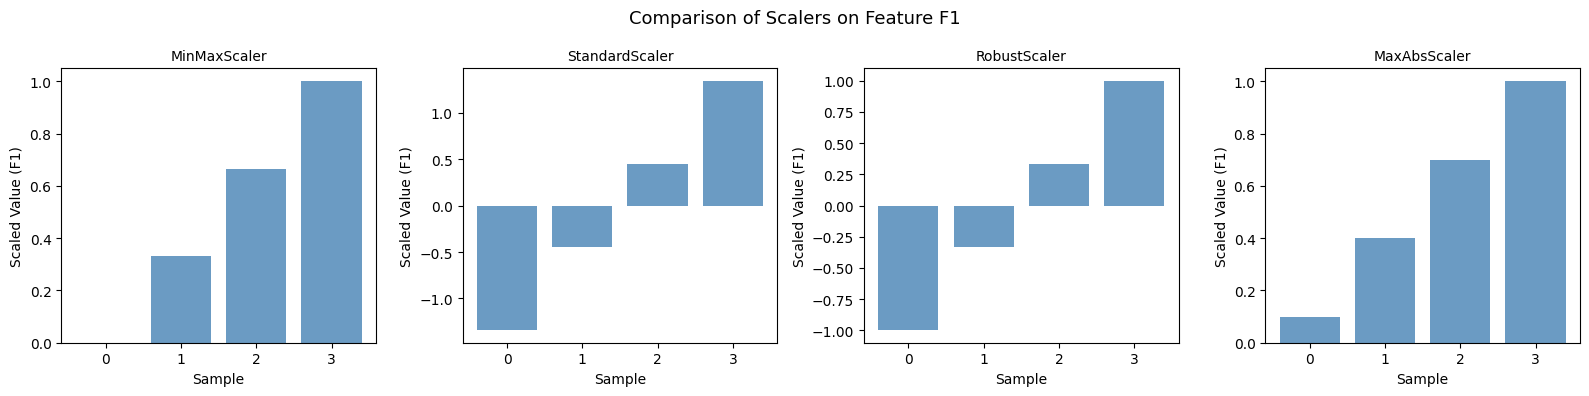

In [34]:
# Visual comparison of column F1 across scalers
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, (name, scaled) in zip(axes, results.items()):
    ax.bar(range(4), scaled[:, 0], color="steelblue", alpha=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Scaled Value (F1)")
    ax.set_xticks(range(4))

plt.suptitle("Comparison of Scalers on Feature F1", fontsize=13)
plt.tight_layout()
plt.show()

---
## Ejercicio 14: Pipeline de Preprocesamiento

In [35]:
# --- Exercise 14: Preprocessing Pipeline ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Sample dataset with numeric and categorical columns
df = pd.DataFrame({
    "age": [25, 30, np.nan, 35, 40],
    "income": [50000, 60000, 55000, np.nan, 70000],
    "city": ["CDMX", "GDL", "MTY", "CDMX", "GDL"],
    "education": ["bachelor", "master", "bachelor", "phd", "master"],
})

print("Original DataFrame:")
print(df)
print()

# Define column types
numeric_features = ["age", "income"]
categorical_features = ["city", "education"]

Original DataFrame:
    age   income  city education
0  25.0  50000.0  CDMX  bachelor
1  30.0  60000.0   GDL    master
2   NaN  55000.0   MTY  bachelor
3  35.0      NaN  CDMX       phd
4  40.0  70000.0   GDL    master



In [36]:
# Numeric pipeline: impute with mean, then scale
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

# Categorical pipeline: impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# Fit and transform
result = preprocessor.fit_transform(df)

# Get feature names
cat_features = (
    preprocessor
    .named_transformers_["cat"]["encoder"]
    .get_feature_names_out(categorical_features)
)
all_features = list(numeric_features) + list(cat_features)

df_processed = pd.DataFrame(result, columns=all_features)
print("Processed DataFrame:")
print(df_processed)

Processed DataFrame:
   age    income  city_CDMX  city_GDL  city_MTY  education_bachelor  \
0 -1.5 -1.322876        1.0       0.0       0.0                 1.0   
1 -0.5  0.188982        0.0       1.0       0.0                 0.0   
2  0.0 -0.566947        0.0       0.0       1.0                 1.0   
3  0.5  0.000000        1.0       0.0       0.0                 0.0   
4  1.5  1.700840        0.0       1.0       0.0                 0.0   

   education_master  education_phd  
0               0.0            0.0  
1               1.0            0.0  
2               0.0            0.0  
3               0.0            1.0  
4               1.0            0.0  


---
## Ejercicio 15: Mejores Prácticas (Investigación)

### 1. ¿Por qué es importante la preparación de datos?
- Los modelos de ML son sensibles a la calidad de los datos.
- Datos sucios (NaN, outliers, escalas diferentes) producen modelos con pobre rendimiento.
- "Garbage in, garbage out": se estima que el 80% del tiempo en un proyecto de ciencia de datos se dedica a la limpieza y preparación.

### 2. ¿Qué es data leakage y cómo evitarlo?
- **Data leakage** ocurre cuando información del conjunto de prueba "se filtra" al entrenamiento, produciendo métricas artificialmente buenas.
- Ejemplo: escalar TODOS los datos antes de dividir en train/test — el scaler conoce estadísticas del test set.
- **Cómo evitarlo:**
  - Siempre dividir train/test **antes** de preprocesar.
  - Usar `fit_transform` solo en train y `transform` en test.
  - Usar `Pipeline` de sklearn para encapsular preprocesamiento + modelo.

### 3. ¿Cuál es la diferencia entre datos de entrenamiento y prueba?
| Aspecto | Train | Test |
|---------|-------|------|
| Propósito | Aprender patrones | Evaluar generalización |
| El modelo los ve | Sí | No (durante entrenamiento) |
| Proporción típica | 70-80% | 20-30% |
| Preprocesamiento | `fit_transform` | Solo `transform` |

In [37]:
# --- Exercise 15: Practical Demo of Data Leakage ---
from sklearn.model_selection import train_test_split

# Example: correct way to preprocess
np.random.seed(42)
X = np.random.randn(100, 3) * 10 + 50
y = np.random.randint(0, 2, 100)

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# THEN fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on TRAIN
X_test_scaled = scaler.transform(X_test)         # only transform on TEST

print("✅ Correct approach (no data leakage):")
print(f"   Train mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"   Train std:  {X_train_scaled.std(axis=0).round(4)}")
print(f"   Test mean:  {X_test_scaled.mean(axis=0).round(4)} (not exactly 0)")
print(f"   Test std:   {X_test_scaled.std(axis=0).round(4)} (not exactly 1)")

✅ Correct approach (no data leakage):
   Train mean: [-0. -0.  0.]
   Train std:  [1. 1. 1.]
   Test mean:  [ 0.0139  0.2668 -0.3528] (not exactly 0)
   Test std:   [0.8757 1.3623 0.8274] (not exactly 1)


---
## Ejercicio 16: Técnicas Avanzadas (Investigación)

### 1. ¿Qué es SMOTE?
- **SMOTE** (Synthetic Minority Over-sampling Technique) genera muestras sintéticas de la clase minoritaria.
- Funciona interpolando entre vecinos cercanos de la clase minoritaria.
- Útil cuando hay **desbalance de clases** (ej: 95% clase 0, 5% clase 1).
- Librería: `imblearn` (`from imblearn.over_sampling import SMOTE`).

### 2. ¿Qué es la imputación por KNN?
- `KNNImputer` imputa valores faltantes usando los **K vecinos más cercanos**.
- Para cada valor NaN, encuentra las K filas más similares y promedia sus valores.
- Mejor que imputar con la media cuando hay correlaciones entre variables.
- `from sklearn.impute import KNNImputer`.

### 3. ¿Qué es Target Encoding?
- Reemplaza cada categoría con la **media de la variable objetivo** para esa categoría.
- Ejemplo: si `ciudad="CDMX"` tiene promedio de ventas = 5000, se reemplaza "CDMX" → 5000.
- **Riesgo**: puede causar overfitting y data leakage si no se hace con cuidado (usar regularización o cross-validation).

In [38]:
# --- Exercise 16: KNNImputer Demo ---
from sklearn.impute import KNNImputer

df_demo = pd.DataFrame({
    "A": [1, 2, np.nan, 4, 5],
    "B": [2, np.nan, 6, 8, 10],
    "C": [10, 20, 30, 40, 50],
})

print("Before KNNImputer:")
print(df_demo)
print()

knn_imputer = KNNImputer(n_neighbors=2)
result = knn_imputer.fit_transform(df_demo)
df_imputed = pd.DataFrame(result, columns=df_demo.columns)

print("After KNNImputer (k=2):")
print(df_imputed)

Before KNNImputer:
     A     B   C
0  1.0   2.0  10
1  2.0   NaN  20
2  NaN   6.0  30
3  4.0   8.0  40
4  5.0  10.0  50

After KNNImputer (k=2):
     A     B     C
0  1.0   2.0  10.0
1  2.0   4.0  20.0
2  3.0   6.0  30.0
3  4.0   8.0  40.0
4  5.0  10.0  50.0


---
## Resumen Final

| Técnica | Cuándo usarla |
|---------|---------------|
| **MinMaxScaler** | Rango fijo [0,1], sin outliers extremos |
| **StandardScaler** | Datos ~ normales, algoritmos sensibles a escala |
| **RobustScaler** | Datos con muchos outliers |
| **dropna()** | Pocos NaN, muchos datos |
| **SimpleImputer(mean)** | NaN en datos numéricos sin outliers |
| **KNNImputer** | Correlación entre features, mejor calidad de imputación |
| **IQR / Z-Score** | Detección de outliers |
| **Log / Box-Cox** | Reducir skewness, estabilizar varianza |
| **One-Hot Encoding** | Variables categóricas nominales (sin orden) |
| **Label Encoding** | Variables categóricas ordinales (con orden) |
| **Pipeline** | Producción, evitar data leakage |
